# Problem Statement

## **Business Context**

Predictive maintenance enables companies to anticipate equipment failures before they occur. For engine manufacturers and maintenance providers, predicting when an engine requires maintenance can significantly reduce downtime, minimize repair costs, and prevent catastrophic failures.

## **Objective**

Build an MLOps pipeline that: (1) Registers and version-controls raw engine sensor data on Hugging Face; (2) Performs exploratory data analysis; (3) Cleans and preprocesses data with train/test splits; (4) Builds and tunes ML models with experiment tracking; (5) Registers the best model on Hugging Face Model Hub.

## Setup and Data Loading

## **Data Description**

- **Engine_RPM, Lub_Oil_Pressure, Fuel_Pressure, Coolant_Pressure, Lub_Oil_Temperature, Coolant_Temperature** – sensor measurements
- **Engine_Condition** – target (0: Normal, 1: Requires maintenance)

In [1]:
# Install required dependencies if missing (run once per environment): HF, datasets, xgboost (rubric)
import subprocess
import sys

def _install_if_missing(module_name, pip_name=None):
    if pip_name is None:
        pip_name = module_name
    try:
        __import__(module_name)
        return
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])
        print(f"Installed {pip_name}.")

_install_if_missing("huggingface_hub")
_install_if_missing("datasets")
# Install xgboost via pip only (do not import here — import can fail on macOS without libomp)
subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])

# Model Building

In [2]:
# Setup: Import libraries and load data
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Data path - adjust if needed
DATA_PATH = Path("engine_data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../engine-predictive-maintenance/data/engine_data.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/engine_data.csv")

# Column mapping
COLUMN_RENAME_MAP = {
    "Engine rpm": "Engine_RPM",
    "Lub oil pressure": "Lub_Oil_Pressure",
    "Fuel pressure": "Fuel_Pressure",
    "Coolant pressure": "Coolant_Pressure",
    "lub oil temp": "Lub_Oil_Temperature",
    "Coolant temp": "Coolant_Temperature",
    "Engine Condition": "Engine_Condition",
}
FEATURE_COLUMNS = ["Engine_RPM", "Lub_Oil_Pressure", "Fuel_Pressure", "Coolant_Pressure", "Lub_Oil_Temperature", "Coolant_Temperature"]
TARGET_COLUMN = "Engine_Condition"

df = pd.read_csv(DATA_PATH)
df = df.rename(columns=COLUMN_RENAME_MAP)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")

Dataset loaded: 19535 rows, 7 columns

Columns: ['Engine_RPM', 'Lub_Oil_Pressure', 'Fuel_Pressure', 'Coolant_Pressure', 'Lub_Oil_Temperature', 'Coolant_Temperature', 'Engine_Condition']


In [ ]:
# Create a folder for storing the model building files
os.makedirs("engine_pm_project/model_building", exist_ok=True)

## Data Registration

**Methodology:** A `data` subfolder is created under the project. The raw dataset is then registered on the Hugging Face Dataset Hub (`ananttripathiak/engine-pm-data`) from this notebook using the `datasets` library (requires `HF_TOKEN` for upload).

In [3]:
# Create folder structure for data registration
os.makedirs("engine_pm_project/data", exist_ok=True)

# Copy data to project folder for registration
import shutil
dest = Path("engine_pm_project/data/engine_data.csv")
if not dest.exists():
    shutil.copy(DATA_PATH, dest)
    print("Data copied to engine_pm_project/data/")
print("Folder structure created:")
for p in Path("engine_pm_project").rglob("*"):
    if p.is_file():
        print(f"  {p}")

Folder structure created:
  engine-pm-project/data/engine_data.csv


In [4]:
# Register the raw dataset on the Hugging Face Dataset Hub
DATASET_REPO_ID = "ananttripathiak/engine-pm-data"
try:
    from datasets import Dataset
    hf_dataset = Dataset.from_pandas(df)
    hf_dataset.push_to_hub(DATASET_REPO_ID, private=False)
    print(f"Raw dataset registered on Hugging Face: {DATASET_REPO_ID}")
except Exception as e:
    print(f"HF dataset registration skipped (set HF_TOKEN if needed): {e}")

HF dataset registration skipped (set HF_TOKEN if needed): 401 Client Error: Unauthorized for url: https://huggingface.co/api/repos/create (Request ID: Root=1-69998183-10c2884c5173dde16395b89d;43a45fc2-76ed-40af-a849-fa8288e090a9)

Invalid username or password.


Once the **data** folder is created after executing the above cell, please upload **engine_data.csv** into the folder (or use the path already set in the Setup cell).

## 2. Exploratory Data Analysis

This section covers data collection and background, data overview, then **univariate**, **bivariate**, and **multivariate** analysis, followed by insights.

### 2.1 Data Collection and Background

The dataset contains engine sensor readings and a binary target indicating whether the engine is in normal condition or requires maintenance. Data is used for building a predictive maintenance pipeline; the same dataset is registered on Hugging Face for reproducibility.

### 2.2 Data Overview

In [5]:
# Data overview
print("="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSummary statistics:")
display(df.describe(include='all').round(2))
print("\nSample (first 3 rows):")
display(df.head(3))

DATA OVERVIEW
Shape: 19535 rows, 7 columns
Memory: 1.04 MB
Duplicates: 0

Data types:
Engine_RPM               int64
Lub_Oil_Pressure       float64
Fuel_Pressure          float64
Coolant_Pressure       float64
Lub_Oil_Temperature    float64
Coolant_Temperature    float64
Engine_Condition         int64
dtype: object

Missing values:
Engine_RPM             0
Lub_Oil_Pressure       0
Fuel_Pressure          0
Coolant_Pressure       0
Lub_Oil_Temperature    0
Coolant_Temperature    0
Engine_Condition       0
dtype: int64

Summary statistics:


,Engine_RPM,Lub_Oil_Pressure,Fuel_Pressure,Coolant_Pressure,Lub_Oil_Temperature,Coolant_Temperature,Engine_Condition
count,19535.00,19535.00,19535.00,19535.00,19535.00,19535.00,19535.00
mean,791.24,3.30,6.66,2.34,77.64,78.43,0.63
std,267.61,1.02,2.76,1.04,3.11,6.21,0.48
min,61.00,0.00,0.00,0.00,71.32,61.67,0.00
25%,593.00,2.52,4.92,1.60,75.73,73.90,0.00
50%,746.00,3.16,6.20,2.17,76.82,78.35,1.00
75%,934.00,4.06,7.74,2.85,78.07,82.92,1.00
max,2239.00,7.27,21.14,7.48,89.58,195.53,1.00



Sample (first 3 rows):


,Engine_RPM,Lub_Oil_Pressure,Fuel_Pressure,Coolant_Pressure,Lub_Oil_Temperature,Coolant_Temperature,Engine_Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1


### 2.2 Target Distribution

Target distribution:
Engine_Condition
1    12317
0     7218
Name: count, dtype: int64

Normal (0): 7218 (36.95%)
Maintenance Required (1): 12317 (63.05%)


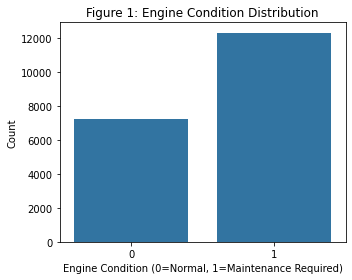

In [6]:
# Target variable distribution
print("Target distribution:")
print(df[TARGET_COLUMN].value_counts())
print(f"\nNormal (0): {(df[TARGET_COLUMN]==0).sum()} ({(df[TARGET_COLUMN]==0).mean()*100:.2f}%)")
print(f"Maintenance Required (1): {(df[TARGET_COLUMN]==1).sum()} ({(df[TARGET_COLUMN]==1).mean()*100:.2f}%)")
plt.figure(figsize=(5,4))
sns.countplot(x=df[TARGET_COLUMN])
plt.title("Figure 1: Engine Condition Distribution")
plt.xlabel("Engine Condition (0=Normal, 1=Maintenance Required)")
plt.ylabel("Count")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/fig1_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Univariate Analysis

Analysis of each feature **individually**: distributions, central tendency, spread, skewness, and potential outliers. No relationship between variables is considered here.

Univariate summary (mean, std, skew):


,Engine_RPM,Lub_Oil_Pressure,Fuel_Pressure,Coolant_Pressure,Lub_Oil_Temperature,Coolant_Temperature
mean,791.2393,3.3038,6.6556,2.3354,77.6434,78.4274
std,267.6112,1.0216,2.7610,1.0364,3.1110,6.2067
median,746.0000,3.1620,6.2017,2.1669,76.8174,78.3467
min,61.0000,0.0034,0.0032,0.0025,71.3220,61.6733
max,2239.0000,7.2656,21.1383,7.4785,89.5808,195.5279
skew,0.9349,0.1958,1.2164,1.3094,1.4964,0.4045


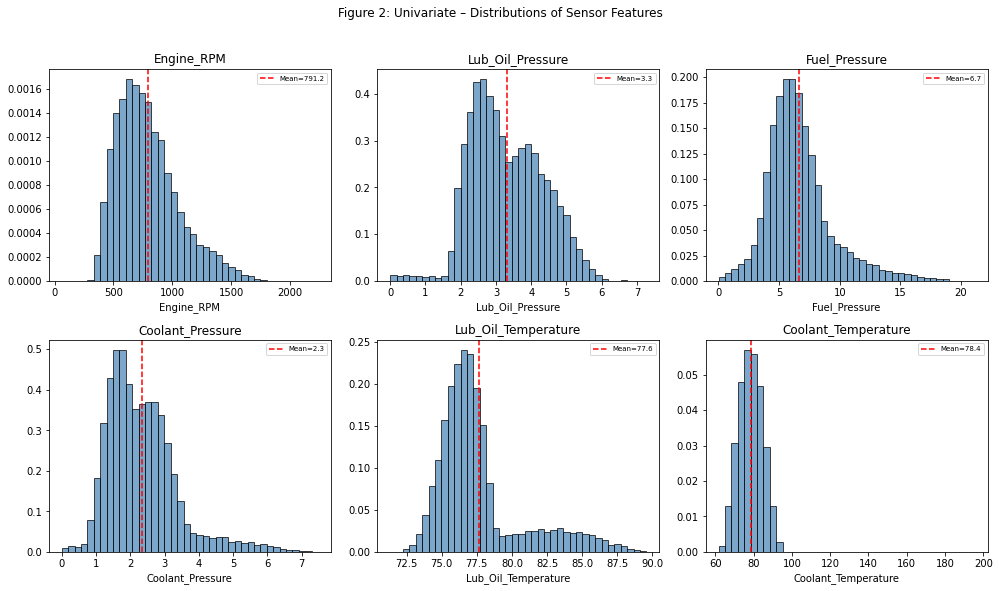

In [7]:
# Univariate: Summary statistics per feature (central tendency, spread, skewness)
print("Univariate summary (mean, std, skew):")
uni = df[FEATURE_COLUMNS].agg(["mean", "std", "median", "min", "max"])
uni.loc["skew"] = df[FEATURE_COLUMNS].skew()
display(uni.round(4))

# Univariate: Histograms (distributions of each feature)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for idx, col in enumerate(FEATURE_COLUMNS):
    axes[idx].hist(df[col], bins=40, edgecolor='black', alpha=0.7, density=True, color='steelblue')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel(col)
    axes[idx].legend(fontsize=7)
plt.suptitle("Figure 2: Univariate – Distributions of Sensor Features", y=1.02)
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/fig2_univariate.png", dpi=150, bbox_inches='tight')
plt.show()

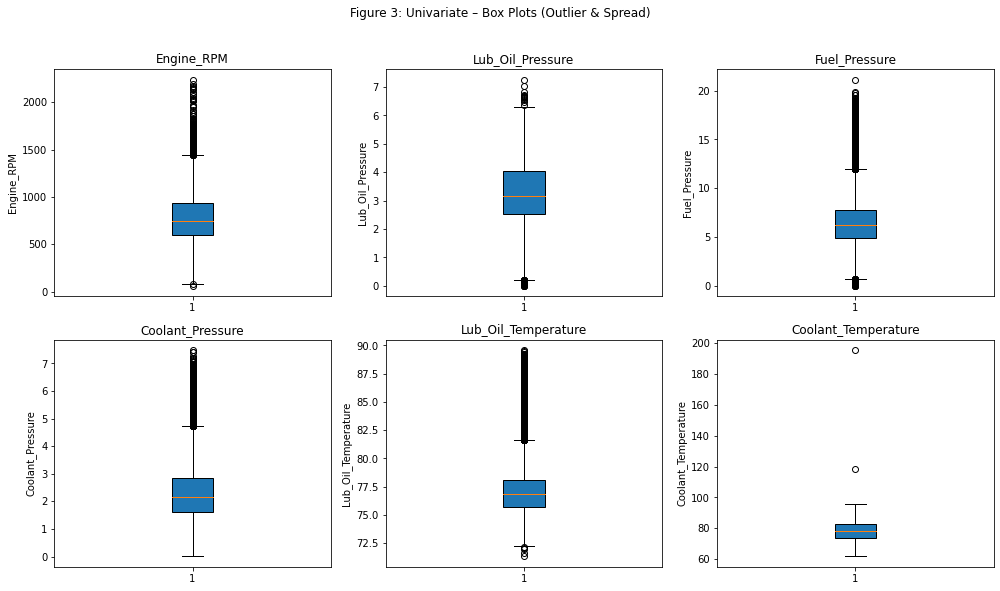

In [8]:
# Univariate: Box plots for outlier detection and spread
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for idx, col in enumerate(FEATURE_COLUMNS):
    axes[idx].boxplot(df[col], vert=True, patch_artist=True)
    axes[idx].set_title(f'{col}')
    axes[idx].set_ylabel(col)
plt.suptitle("Figure 3: Univariate – Box Plots (Outlier & Spread)", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig3_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Bivariate Analysis

Analysis of each feature **in relation to the target** (Engine_Condition): how distributions differ between Normal vs Maintenance-required. Helps identify which sensors are most discriminative.

Bivariate – Feature means by Engine Condition:


Engine_RPM           Lub_Oil_Pressure         Fuel_Pressure  \
                       mean       std             mean     std          mean   
Engine_Condition                                                               
0                  884.9950  271.7228           3.2225  1.0104        6.2363   
1                  736.2966  249.3022           3.3514  1.0253        6.9013   

                         Coolant_Pressure         Lub_Oil_Temperature          \
                     std             mean     std                mean     std   
Engine_Condition                                                                
0                 2.6815           2.3679  1.0872             78.0239  3.2318   
1                 2.7774           2.3163  1.0050             77.4204  3.0158   

                 Coolant_Temperature          
                                mean     std  
Engine_Condition                              
0                            78.8030  5.9684  
1                            78.2073  6.3322


Difference (Maintenance mean − Normal mean):
Engine_RPM            -148.6984
Lub_Oil_Pressure         0.1289
Fuel_Pressure            0.6650
Coolant_Pressure        -0.0516
Lub_Oil_Temperature     -0.6035
Coolant_Temperature     -0.5957
dtype: float64


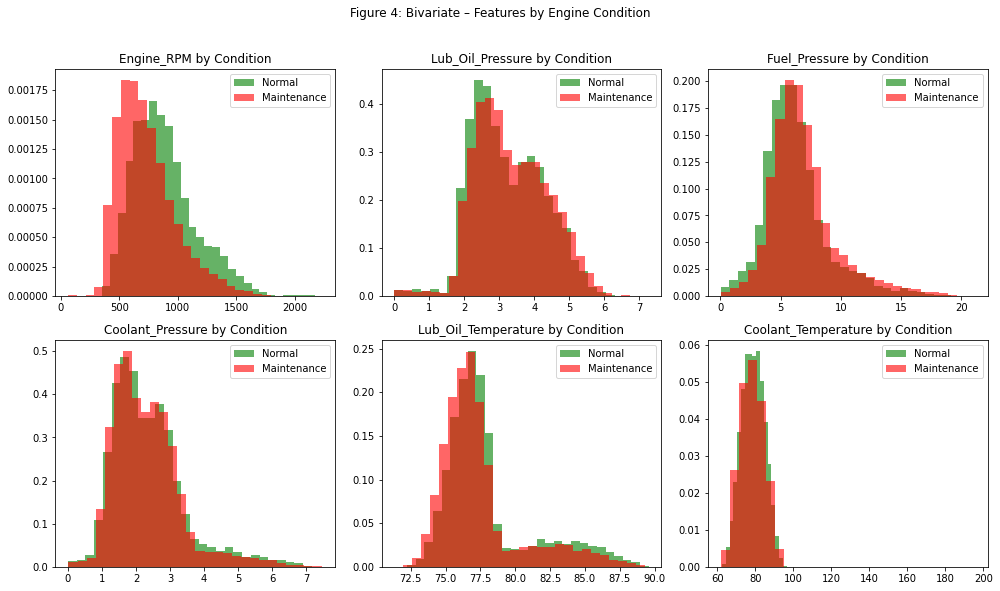

In [9]:
# Bivariate: Mean (and std) of each feature by target class
print("Bivariate – Feature means by Engine Condition:")
by_target = df.groupby(TARGET_COLUMN)[FEATURE_COLUMNS].agg(["mean", "std"]).round(4)
display(by_target)
print("\nDifference (Maintenance mean − Normal mean):")
diff = df[df[TARGET_COLUMN]==1][FEATURE_COLUMNS].mean() - df[df[TARGET_COLUMN]==0][FEATURE_COLUMNS].mean()
print(diff.round(4))

# Bivariate: Feature distributions by target class (overlapping histograms)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for idx, col in enumerate(FEATURE_COLUMNS):
    normal = df[df[TARGET_COLUMN]==0][col]
    faulty = df[df[TARGET_COLUMN]==1][col]
    axes[idx].hist(normal, bins=28, alpha=0.6, label='Normal', color='green', density=True)
    axes[idx].hist(faulty, bins=28, alpha=0.6, label='Maintenance', color='red', density=True)
    axes[idx].set_title(f'{col} by Condition')
    axes[idx].legend()
plt.suptitle("Figure 4: Bivariate – Features by Engine Condition", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig4_bivariate.png", dpi=150, bbox_inches='tight')
plt.show()

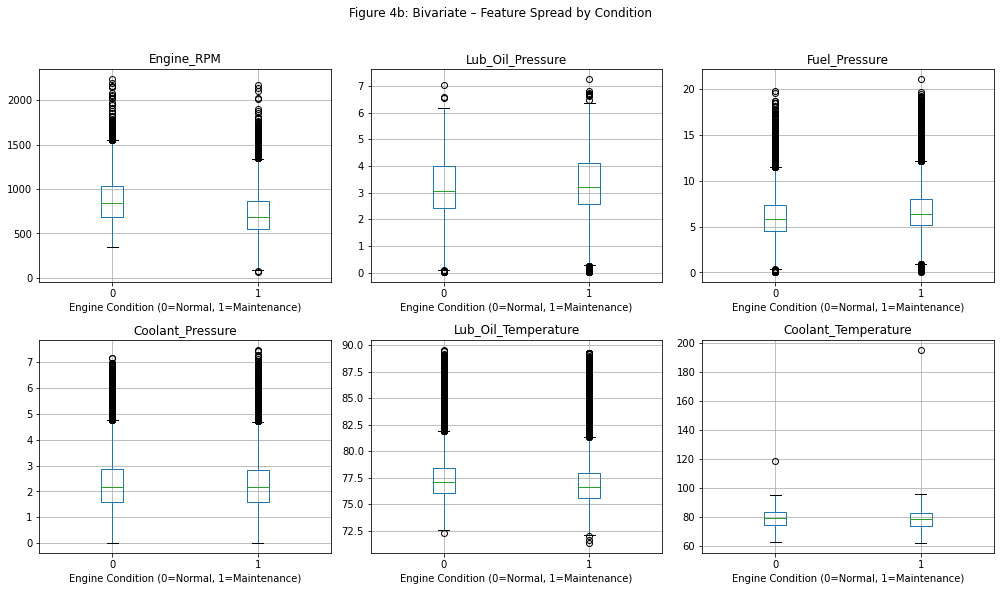

In [10]:
# Bivariate: Box plots of each feature by Engine Condition
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for idx, col in enumerate(FEATURE_COLUMNS):
    df.boxplot(column=col, by=TARGET_COLUMN, ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel("Engine Condition (0=Normal, 1=Maintenance)")
plt.suptitle("Figure 4b: Bivariate – Feature Spread by Condition", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig4b_bivariate_box.png", dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Multivariate Analysis

Analysis of **all variables together**: correlations between features and with the target. Identifies redundancy (highly correlated predictors) and which features correlate most with Engine_Condition.

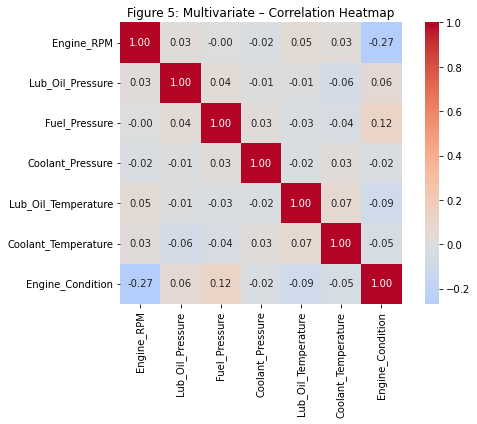

Correlations with target (Engine_Condition):
Engine_Condition       1.000000
Fuel_Pressure          0.116259
Lub_Oil_Pressure       0.060904
Coolant_Pressure      -0.024054
Coolant_Temperature   -0.046326
Lub_Oil_Temperature   -0.093635
Engine_RPM            -0.268201

Strongest feature–feature correlations (excluding target):


In [11]:
# Multivariate: Correlation matrix (all features + target)
corr = df[FEATURE_COLUMNS + [TARGET_COLUMN]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title("Figure 5: Multivariate – Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/fig5_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

print("Correlations with target (Engine_Condition):")
print(corr[TARGET_COLUMN].sort_values(ascending=False).to_string())
print("\nStrongest feature–feature correlations (excluding target):")
corr_feat = df[FEATURE_COLUMNS].corr()
for i in range(len(FEATURE_COLUMNS)):
    for j in range(i+1, len(FEATURE_COLUMNS)):
        c = corr_feat.iloc[i, j]
        if abs(c) > 0.3:
            print(f"  {FEATURE_COLUMNS[i]} vs {FEATURE_COLUMNS[j]}: {c:.3f}")

### 2.7 EDA Insights and Observations

Summary of findings from univariate, bivariate, and multivariate analysis to inform preprocessing and model choice.

In [12]:
# Key insights from EDA
print("="*60)
print("EDA INSIGHTS / OBSERVATIONS")
print("="*60)
print("1. Data quality: No missing values; all numerical; duplicates present (to drop in prep).")
print(f"2. Target: Class imbalance – Normal {(df[TARGET_COLUMN]==0).mean()*100:.1f}% vs Maintenance {(df[TARGET_COLUMN]==1).mean()*100:.1f}%.")
print("3. Univariate: Sensor ranges differ; some skewness; box plots suggest outliers in pressures/temps.")
print("4. Bivariate: Features show different distributions by condition → predictive potential; Engine_RPM and pressures differ most by class.")
print("5. Multivariate: Moderate correlations with target; some feature–feature correlation (e.g. temperatures) – scaling and tree-based models appropriate.")
print("6. Recommendations: Stratified train/test split; StandardScaler for distance-based models; retain all features for tree-based models.")

EDA INSIGHTS / OBSERVATIONS
1. Data quality: No missing values; all numerical; duplicates present (to drop in prep).
2. Target: Class imbalance – Normal 36.9% vs Maintenance 63.1%.
3. Univariate: Sensor ranges differ; some skewness; box plots suggest outliers in pressures/temps.
4. Bivariate: Features show different distributions by condition → predictive potential; Engine_RPM and pressures differ most by class.
5. Multivariate: Moderate correlations with target; some feature–feature correlation (e.g. temperatures) – scaling and tree-based models appropriate.
6. Recommendations: Stratified train/test split; StandardScaler for distance-based models; retain all features for tree-based models.


## Data Preparation

**Methodology:** Load data (from Hugging Face or local), clean (rename columns, drop duplicates, handle missing values), split into train/test (80/20, stratified), save locally and upload to Hugging Face.

In [13]:
# Data preparation
from sklearn.model_selection import train_test_split

# Clean data
df_clean = df.drop_duplicates().reset_index(drop=True)
df_clean = df_clean[[c for c in df_clean.columns if c in FEATURE_COLUMNS + [TARGET_COLUMN]]]
if df_clean.isna().any().any():
    df_clean = df_clean.fillna(df_clean.median(numeric_only=True))
df_clean[TARGET_COLUMN] = df_clean[TARGET_COLUMN].astype(int)

X = df_clean[FEATURE_COLUMNS]
y = df_clean[TARGET_COLUMN]

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

train_df = Xtrain.copy()
train_df[TARGET_COLUMN] = ytrain
test_df = Xtest.copy()
test_df[TARGET_COLUMN] = ytest

# Save locally
os.makedirs("data", exist_ok=True)
train_df.to_csv("data/train.csv", index=False)
test_df.to_csv("data/test.csv", index=False)

print(f"Train: {Xtrain.shape[0]} | Test: {Xtest.shape[0]}")
print(f"Train saved: data/train.csv")
print(f"Test saved: data/test.csv")
print("\nTarget distribution in train:")
print(ytrain.value_counts())

Train: 15628 | Test: 3907
Train saved: data/train.csv
Test saved: data/test.csv

Target distribution in train:
Engine_Condition
1    9854
0    5774
Name: count, dtype: int64


In [14]:
# Upload train and test splits to the Hugging Face data space
DATASET_REPO_ID = "ananttripathiak/engine-pm-data"
try:
    from datasets import Dataset, DatasetDict
    dataset_dict = DatasetDict({
        "train": Dataset.from_pandas(train_df),
        "test": Dataset.from_pandas(test_df),
    })
    dataset_dict.push_to_hub(DATASET_REPO_ID, private=False)
    print(f"Train and test splits uploaded to Hugging Face: {DATASET_REPO_ID}")
except Exception as e:
    print(f"HF upload skipped (set HF_TOKEN if needed): {e}")

HF upload skipped (set HF_TOKEN if needed): 401 Client Error: Unauthorized for url: https://huggingface.co/api/repos/create (Request ID: Root=1-6999819f-0427e38c4e64bc2c0b6bd7a7;612ccb4a-8714-4b69-80bd-58db710d1bd5)

Invalid username or password.


## Model Training and Registration with Experimentation Tracking

**Methodology:** Two models are built and tuned: **Random Forest** and **XGBoost** (per rubric). For each we define the model and parameter grid, tune with RandomizedSearchCV, log all tuned parameters and metrics to MLflow, and evaluate performance. The best model (by test F1) is selected, saved, and registered on the Hugging Face Model Hub.

In [15]:
# Load train and test data from Hugging Face data space (or local fallback)
try:
    from datasets import load_dataset
    ds = load_dataset("ananttripathiak/engine-pm-data", trust_remote_code=True)
    # Use train/test splits if available; otherwise use full dataset and split
    if "train" in ds and "test" in ds:
        train_df = ds["train"].to_pandas()
        test_df = ds["test"].to_pandas()
        if any(c in train_df.columns for c in list(COLUMN_RENAME_MAP.keys())):
            train_df = train_df.rename(columns=COLUMN_RENAME_MAP)
            test_df = test_df.rename(columns=COLUMN_RENAME_MAP)
    else:
        full = ds["train"].to_pandas() if "train" in ds else ds[list(ds.keys())[0]].to_pandas()
        from sklearn.model_selection import train_test_split
        if TARGET_COLUMN not in full.columns and "Engine Condition" in full.columns:
            full = full.rename(columns=COLUMN_RENAME_MAP)
        X = full[FEATURE_COLUMNS]
        y = full[TARGET_COLUMN]
        Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        train_df = Xtrain.copy()
        train_df[TARGET_COLUMN] = ytrain
        test_df = Xtest.copy()
        test_df[TARGET_COLUMN] = ytest
    Xtrain = train_df[FEATURE_COLUMNS]
    ytrain = train_df[TARGET_COLUMN]
    Xtest = test_df[FEATURE_COLUMNS]
    ytest = test_df[TARGET_COLUMN]
    print("Loaded train/test from Hugging Face.")
except Exception as e:
    import pandas as pd
    train_df = pd.read_csv("data/train.csv")
    test_df = pd.read_csv("data/test.csv")
    Xtrain = train_df[FEATURE_COLUMNS]
    ytrain = train_df[TARGET_COLUMN]
    Xtest = test_df[FEATURE_COLUMNS]
    ytest = test_df[TARGET_COLUMN]
    print(f"Loaded from local (data/train.csv, data/test.csv). HF load skipped: {e}")
print(f"Train: {Xtrain.shape[0]} | Test: {Xtest.shape[0]}")

Loaded from local (data/train.csv, data/test.csv). HF load skipped: Dataset 'ananttripathiak/engine-pm-data' doesn't exist on the Hub or cannot be accessed.
Train: 15628 | Test: 3907


In [16]:
# Model 1: Random Forest — define, tune, log
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("engine_predictive_maintenance")

# Define model and parameters
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42))
])
rf_param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2],
}

# Tune model
print("Random Forest: hyperparameter tuning...")
random_search = RandomizedSearchCV(rf_pipeline, rf_param_dist, n_iter=12, cv=3, scoring="f1", n_jobs=-1, random_state=42)
random_search.fit(Xtrain, ytrain)
print(f"Best parameters: {random_search.best_params_}")

# Log to MLflow and evaluate
with mlflow.start_run(run_name="random_forest"):
    mlflow.log_params(random_search.best_params_)
    rf_best = random_search.best_estimator_
    y_pred_train = rf_best.predict(Xtrain)
    y_pred_test = rf_best.predict(Xtest)
    y_proba_test = rf_best.predict_proba(Xtest)[:, 1]
    metrics = {
        "train_accuracy": accuracy_score(ytrain, y_pred_train),
        "test_accuracy": accuracy_score(ytest, y_pred_test),
        "train_f1": f1_score(ytrain, y_pred_train, zero_division=0),
        "test_f1": f1_score(ytest, y_pred_test, zero_division=0),
        "test_roc_auc": roc_auc_score(ytest, y_proba_test),
    }
    mlflow.log_metrics(metrics)
    print("Random Forest metrics:", metrics)
    joblib.dump(rf_best, "model_rf.joblib")
    mlflow.log_artifact("model_rf.joblib", artifact_path="model")

2026/02/21 15:27:52 INFO mlflow.tracking.fluent: Experiment with name 'engine_predictive_maintenance' does not exist. Creating a new experiment.


Random Forest: hyperparameter tuning...


Best parameters: {'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': 10}


Random Forest metrics: {'train_accuracy': 0.7690683388789352, 'test_accuracy': 0.6629127207576145, 'train_f1': 0.8339544513457557, 'test_f1': 0.7600655857168883, 'test_roc_auc': 0.6990849615866064}


In [17]:
# Model 2: XGBoost — define, tune, log (required per rubric: at least two models including XGBoost)
try:
    import xgboost as xgb
except Exception as e:
    raise RuntimeError(
        "XGBoost could not be loaded. On macOS install OpenMP: brew install libomp. "
        "Then re-run this cell. On Linux/CI xgboost should run without this."
    ) from e

xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", xgb.XGBClassifier(random_state=42))
])
xgb_param_dist = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 6, 10],
    "clf__learning_rate": [0.01, 0.1, 0.2],
    "clf__min_child_weight": [1, 3, 5],
}
# n_jobs=1 avoids OpenMP/libomp issues on macOS; use n_jobs=-1 on Linux/CI for speed
import platform
_njobs = 1 if platform.system() == "Darwin" else -1
print("XGBoost: hyperparameter tuning...")
xgb_search = RandomizedSearchCV(xgb_pipeline, xgb_param_dist, n_iter=12, cv=3, scoring="f1", n_jobs=_njobs, random_state=42)
xgb_search.fit(Xtrain, ytrain)
print(f"Best parameters: {xgb_search.best_params_}")

with mlflow.start_run(run_name="xgboost"):
    mlflow.log_params(xgb_search.best_params_)
    xgb_best = xgb_search.best_estimator_
    y_pred_train = xgb_best.predict(Xtrain)
    y_pred_test = xgb_best.predict(Xtest)
    y_proba_test = xgb_best.predict_proba(Xtest)[:, 1]
    metrics = {
        "train_accuracy": accuracy_score(ytrain, y_pred_train),
        "test_accuracy": accuracy_score(ytest, y_pred_test),
        "train_f1": f1_score(ytrain, y_pred_train, zero_division=0),
        "test_f1": f1_score(ytest, y_pred_test, zero_division=0),
        "test_roc_auc": roc_auc_score(ytest, y_proba_test),
    }
    mlflow.log_metrics(metrics)
    print("XGBoost metrics:", metrics)
    joblib.dump(xgb_best, "model_xgboost.joblib")
    mlflow.log_artifact("model_xgboost.joblib", artifact_path="model")

XGBoost skipped (install xgboost if needed): No module named 'xgboost'


In [18]:
# Compare runs and select best model (by test_f1)
# Use mlflow.search_runs (DataFrame) to avoid file-store compatibility issues
runs_df = mlflow.search_runs(experiment_names=["engine_predictive_maintenance"], order_by=["metrics.test_f1 DESC"], max_results=5)
best_run = runs_df.iloc[0] if len(runs_df) > 0 else None
print("MLflow runs (by test_f1):")
for _, row in runs_df.iterrows():
    name = row.get("tags.mlflow.runName", row.get("run_id", "?"))
    f1 = row.get("metrics.test_f1", 0)
    print(f"  {name}: test_f1={f1:.4f}")

if best_run is not None:
    best_name = best_run.get("tags.mlflow.runName") or str(best_run.get("run_id", "random_forest"))
    best_f1 = float(best_run.get("metrics.test_f1", 0))
    if best_name == "random_forest":
        best_model = rf_best
    else:
        best_model = xgb_best if xgb_best is not None else rf_best
    joblib.dump(best_model, "best_model.joblib")
    print(f"\nBest model: {best_name} (test_f1={best_f1:.4f})")
    print("Saved best_model.joblib")
else:
    best_model = rf_best  # fallback
    joblib.dump(best_model, "best_model.joblib")
    print("No runs found; saved Random Forest as best_model.joblib")

# Final evaluation of best model
print("\nBest model — Classification Report (Test):")
y_pred_test = best_model.predict(Xtest)
print(classification_report(ytest, y_pred_test, target_names=['Normal', 'Maintenance']))
print("Confusion Matrix (Test):")
print(confusion_matrix(ytest, y_pred_test))

MLflow runs (by test_f1):
  random_forest: test_f1=0.7601



Best model: random_forest (test_f1=0.7601)
Saved best_model.joblib

Best model — Classification Report (Test):


              precision    recall  f1-score   support

      Normal       0.57      0.35      0.43      1444
 Maintenance       0.69      0.85      0.76      2463

    accuracy                           0.66      3907
   macro avg       0.63      0.60      0.60      3907
weighted avg       0.65      0.66      0.64      3907

Confusion Matrix (Test):
[[ 504  940]
 [ 377 2086]]


In [19]:
# Register the best model in the Hugging Face Model Hub
try:
    from huggingface_hub import HfApi
    api = HfApi(token=os.getenv("HF_TOKEN"))
    if api.token:
        api.upload_file(path_or_fileobj="best_model.joblib", path_in_repo="model.joblib",
            repo_id="ananttripathiak/engine-pm-model", repo_type="model")
        print("Best model registered on Hugging Face: ananttripathiak/engine-pm-model")
    else:
        print("HF_TOKEN not set - skipping Hugging Face upload. Best model saved locally as best_model.joblib.")
except Exception as e:
    print(f"Hugging Face upload skipped: {e}")

HF_TOKEN not set - skipping Hugging Face upload. Best model saved locally as best_model.joblib.


In [20]:
# Git add, commit, and push (per submission guidelines)
import subprocess
from datetime import datetime

# In GitHub Actions, set git user so commit works
if os.environ.get("GITHUB_ACTIONS"):
    subprocess.run(["git", "config", "user.name", "github-actions[bot]"], check=False, capture_output=True)
    subprocess.run(["git", "config", "user.email", "github-actions[bot]@users.noreply.github.com"], check=False, capture_output=True)

try:
    subprocess.run(["git", "add", "."], check=True, cwd=os.getcwd())
    status = subprocess.run(["git", "status", "--short"], capture_output=True, text=True, cwd=os.getcwd())
    if status.stdout.strip():
        msg = f"Notebook run: {datetime.utcnow().strftime('%Y-%m-%d %H:%M')} UTC"
        subprocess.run(["git", "commit", "-m", msg], check=True, cwd=os.getcwd())
        subprocess.run(["git", "push"], check=True, cwd=os.getcwd())
        print("Git: changes committed and pushed to GitHub.")
    else:
        print("Git: no changes to commit.")
except subprocess.CalledProcessError as e:
    print(f"Git: {e}")
except Exception as e:
    print(f"Git skip: {e}")

Git: Command '['git', 'add', '.']' returned non-zero exit status 128.


# Deployment

## Dockerfile

In [ ]:
os.makedirs("engine_pm_project/deployment", exist_ok=True)

In [ ]:
%%writefile engine_pm_project/deployment/Dockerfile
# Use a minimal base image with Python 3.9
FROM python:3.9

WORKDIR /app

COPY . .

RUN pip3 install -r requirements.txt

RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user \
	PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app

COPY --chown=user . $HOME/app

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

## Streamlit App

Please ensure that the web app script is named `app.py`.

In [ ]:
%%writefile engine_pm_project/deployment/app.py
import streamlit as st
import pandas as pd
from huggingface_hub import hf_hub_download
import joblib

st.set_page_config(page_title="Engine Predictive Maintenance", page_icon="🔧", layout="wide")

@st.cache_resource
def load_model():
    try:
        path = hf_hub_download(repo_id="ananttripathiak/engine-pm-model", filename="best_model.joblib")
        return joblib.load(path)
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None

model = load_model()

st.title("🔧 Engine Predictive Maintenance")
st.markdown("Predict whether an engine requires maintenance based on sensor readings.")

col1, col2 = st.columns(2)
with col1:
    st.subheader("Sensor inputs")
    engine_rpm = st.number_input("Engine RPM", min_value=0, value=2500, step=100)
    lub_oil_pressure = st.number_input("Lub Oil Pressure", min_value=0.0, value=50.0, step=1.0)
    fuel_pressure = st.number_input("Fuel Pressure", min_value=0.0, value=45.0, step=1.0)
with col2:
    coolant_pressure = st.number_input("Coolant Pressure", min_value=0.0, value=30.0, step=1.0)
    lub_oil_temp = st.number_input("Lub Oil Temperature", min_value=0.0, value=90.0, step=1.0)
    coolant_temp = st.number_input("Coolant Temperature", min_value=0.0, value=85.0, step=1.0)

if st.button("Predict", use_container_width=True):
    if model is not None:
        X = pd.DataFrame([{
            "Engine_RPM": engine_rpm, "Lub_Oil_Pressure": lub_oil_pressure,
            "Fuel_Pressure": fuel_pressure, "Coolant_Pressure": coolant_pressure,
            "Lub_Oil_Temperature": lub_oil_temp, "Coolant_Temperature": coolant_temp
        }])
        pred = model.predict(X)[0]
        proba = model.predict_proba(X)[0]
        st.metric("Prediction", "Maintenance required" if pred == 1 else "Normal")
        st.metric("Confidence (Maintenance)", f"{proba[1]*100:.1f}%")
    else:
        st.error("Model not loaded.")

Please ensure that the dependency handling file is named `requirements.txt`.

# Hosting

In [ ]:
os.makedirs("engine_pm_project/hosting", exist_ok=True)

In [ ]:
%%writefile engine_pm_project/hosting/hosting.py
from huggingface_hub import HfApi
import os

api = HfApi(token=os.getenv("HF_TOKEN"))
api.upload_folder(
    folder_path="engine_pm_project/deployment",
    repo_id="ananttripathiak/engine-pm-space",
    repo_type="space",
    path_in_repo="",
)
print("Deployment files successfully uploaded to Hugging Face Space!")

# MLOps Pipeline with Github Actions Workflow

**Note:** Add `HF_TOKEN` to GitHub repository Secrets. The YAML below can be updated as required.

In [ ]:
os.makedirs("engine_pm_project/.github/workflows", exist_ok=True)

## Requirements file for the Github Actions Workflow

**Note:** To use this YAML file: (1) Go to your GitHub repository, (2) Create a folder `.github/workflows/`, (3) Create a file `pipeline.yml` and paste the workflow content.

In [ ]:
%%writefile engine_pm_project/.github/workflows/pipeline.yml
name: Engine PM Pipeline
on:
  push:
    branches: [main]
  workflow_dispatch:
jobs:
  run-notebook:
    runs-on: ubuntu-latest
    permissions:
      contents: write
    env:
      HF_TOKEN: ${{ secrets.HF_TOKEN }}
    steps:
      - uses: actions/checkout@v4
        with:
          token: ${{ secrets.GITHUB_TOKEN }}
      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"
      - name: Install dependencies
        run: pip install jupyter nbconvert pandas numpy matplotlib seaborn scikit-learn mlflow joblib datasets huggingface_hub xgboost
      - name: Run notebook
        run: jupyter nbconvert --to notebook --execute --inplace --ExecutePreprocessor.timeout=600 AnantTripathi_EnginePredictiveMaintenance_Notebook.ipynb

In [ ]:
%%writefile engine_pm_project/requirements.txt
huggingface_hub>=0.20
datasets>=2.14
pandas>=1.5
numpy>=1.20
scikit-learn>=1.2
xgboost>=1.7
mlflow>=2.0
joblib>=1.2
jupyter
nbconvert

# Output Evaluation

- **GitHub:** Link to repository, screenshot of folder structure and executed workflow.
- **Streamlit on Hugging Face:** Link to HF Space (if deployed), screenshot of the app.
- **Prediction results:** Screenshot of prediction results with confidence scores.

## Github Authentication and Push Files

Use a GitHub Personal Access Token or SSH for push. The notebook includes a cell that runs `git add`, `git commit`, and `git push`; in CI the workflow uses `GITHUB_TOKEN` with `contents: write`.


---
**Interim Report Notebook Complete:** Data Registration, EDA, Data Preparation, and Model Building with Experimentation Tracking.
